# 01 — Analyse exploratoire (EDA)

Dataset **UCI Diabetes 130-US Hospitals (1999–2008)**, cible `time_in_hospital`.

Objectif : comprendre la donnee avant de figer les regles de `src/data/preprocess.py`.
Ce notebook est de l'**exploration uniquement** — aucun code reutilise ne vit ici
(regle CLAUDE.md : tout ce qui sert en production vit dans `src/`).

Prerequis : `python -m src.data.load`

In [1]:
import sys
from pathlib import Path

# Le notebook vit dans notebooks/ : on remonte a la racine pour importer src.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import RAW_DATA_DIR

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# na_values='?' : dans ce dataset le manquant est encode par un point d'interrogation.
df = pd.read_csv(RAW_DATA_DIR / "diabetic_data.csv", low_memory=False, na_values="?")
print(f"{df.shape[0]:,} sejours x {df.shape[1]} colonnes")
df.head(3)

101,766 sejours x 50 colonnes


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## 1. La cible : `time_in_hospital`

Duree de sejour en jours, bornee 1–14 par construction du dataset.

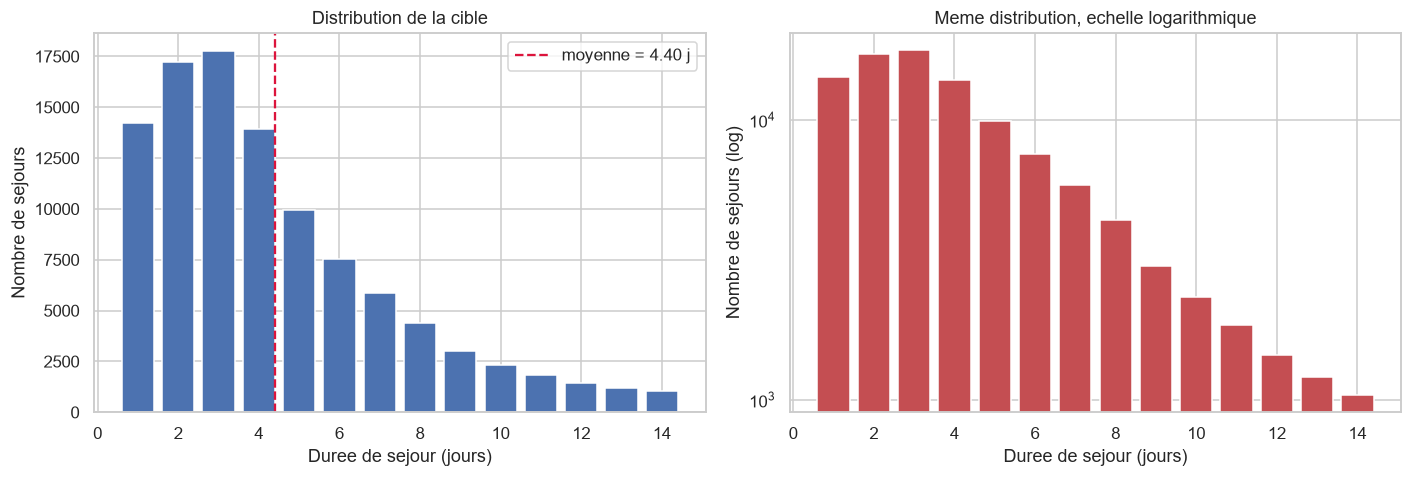

count    101766.00
mean          4.40
std           2.99
min           1.00
25%           2.00
50%           4.00
75%           6.00
max          14.00

Asymetrie (skew) : 1.134  -> queue a droite


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df["time_in_hospital"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=sns.color_palette("deep")[0])
axes[0].axvline(
    df["time_in_hospital"].mean(),
    color="crimson",
    ls="--",
    label=f"moyenne = {df['time_in_hospital'].mean():.2f} j",
)
axes[0].set(
    xlabel="Duree de sejour (jours)",
    ylabel="Nombre de sejours",
    title="Distribution de la cible",
)
axes[0].legend()

# Echelle log : rend lisible la traine droite, ecrasee en echelle lineaire.
axes[1].bar(counts.index, counts.values, color=sns.color_palette("deep")[3])
axes[1].set_yscale("log")
axes[1].set(
    xlabel="Duree de sejour (jours)",
    ylabel="Nombre de sejours (log)",
    title="Meme distribution, echelle logarithmique",
)

plt.tight_layout()
plt.show()

print(df["time_in_hospital"].describe().round(2).to_string())
print(f"\nAsymetrie (skew) : {df['time_in_hospital'].skew():.3f}  -> queue a droite")

**Lecture.** Mode a 3 jours, moyenne (4,40) nettement superieure a la mediane (4) :
distribution asymetrique a droite. Les sejours longs sont rares mais ce sont
precisement les plus couteux a mal anticiper.

C'est l'argument central du projet : une prediction ponctuelle de 4,4 jours ne dit
rien du risque de sejour a 12 jours. Un **intervalle** capture cette incertitude.

## 2. Valeurs manquantes

Le `?` du CSV a ete converti en `NaN` au chargement.

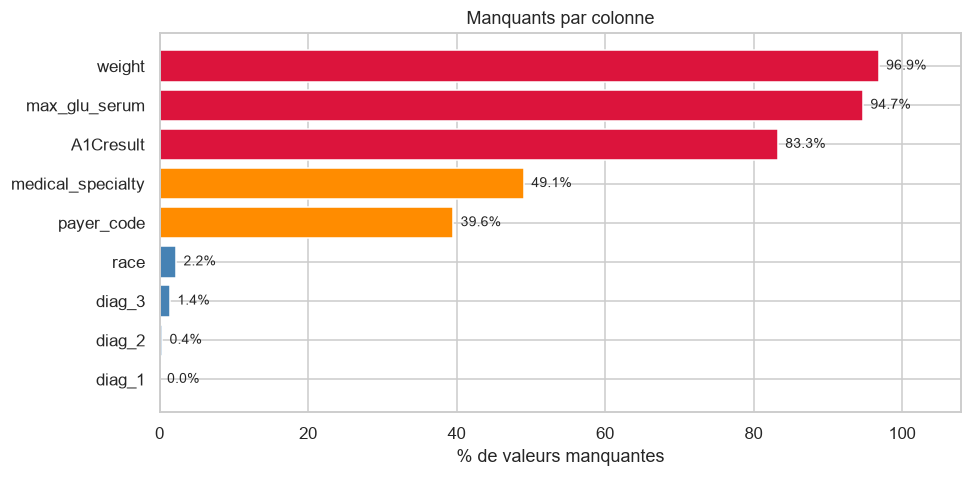

In [3]:
na = df.isna().sum() / len(df) * 100
na = na[na > 0].sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [
    "crimson" if v > 80 else "darkorange" if v > 30 else "steelblue" for v in na.values
]
ax.barh(na.index, na.values, color=colors)
for i, v in enumerate(na.values):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set(xlabel="% de valeurs manquantes", title="Manquants par colonne", xlim=(0, 108))
plt.tight_layout()
plt.show()

**Lecture, et un piege.**

- `weight` (96,9 %) : inexploitable, on drop.
- `max_glu_serum` (94,8 %) et `A1Cresult` (83,3 %) : **ce ne sont pas des manquants**.
  Ce sont des tests *non effectues*. La decision du medecin de doser (ou non) l'HbA1c
  est en soi une information clinique. A traiter comme une modalite `"not_measured"`,
  surtout pas a imputer.
- `medical_specialty` (49,1 %) et `payer_code` (39,6 %) : arbitrage ci-dessous.
- `race` (2,2 %) et `diag_*` (< 1,5 %) : marginal.

## 3. Quelles variables portent du signal ?

Critere : ecart de duree moyenne entre modalites, a effectif suffisant (>= 500 sejours).

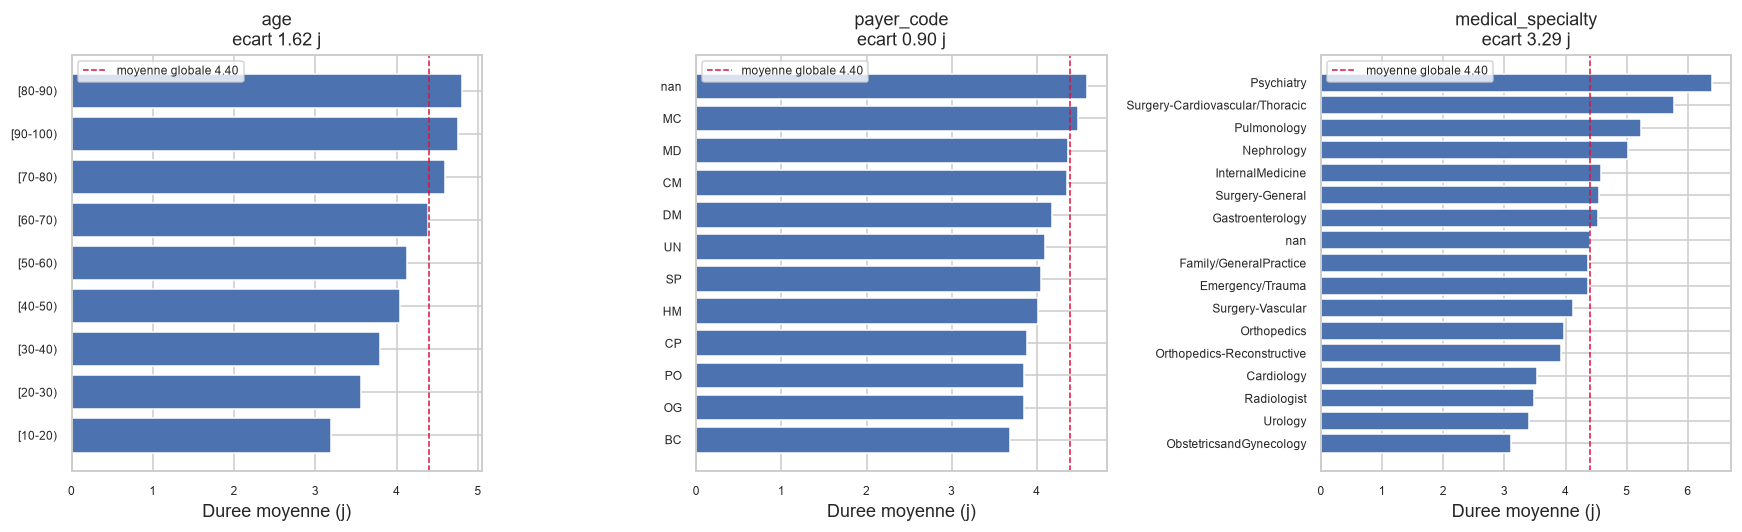

In [4]:
def signal(col, min_count=500):
    g = df.groupby(col, dropna=False)["time_in_hospital"].agg(["mean", "count"])
    return g[g["count"] >= min_count].sort_values("mean")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
moyenne_globale = df["time_in_hospital"].mean()

for ax, col in zip(axes, ["age", "payer_code", "medical_specialty"]):
    g = signal(col)
    ax.barh([str(i) for i in g.index], g["mean"], color=sns.color_palette("deep")[0])
    ax.axvline(
        moyenne_globale,
        color="crimson",
        ls="--",
        lw=1,
        label=f"moyenne globale {moyenne_globale:.2f}",
    )
    ax.set(
        xlabel="Duree moyenne (j)",
        title=f"{col}\necart {g['mean'].max()-g['mean'].min():.2f} j",
    )
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

**Lecture.**

- `age` : croissance monotone (3,2 j chez les 10-20 ans -> 4,8 j chez les 80-90).
  Coherent cliniquement, variable a garder.
- `medical_specialty` : **le signal le plus fort** (3,1 j en gynecologie contre 6,4 j
  en psychiatrie, soit 3,3 j d'ecart sur une moyenne de 4,4). On garde, avec les
  manquants en modalite `"Unknown"` : ne pas renseigner la specialite est
  probablement lie au type de service, donc informatif.
- `payer_code` : signal plus faible (0,9 j). **Decision : on garde.**
  Droper cette variable ne supprimerait pas l'inegalite d'acces aux soins, cela la
  rendrait seulement invisible — le modele la reconstruirait via des proxys (age,
  specialite, diagnostics) sans qu'on puisse la mesurer. On la conserve et on
  verifiera en phase 5 que la couverture a 90 % tient **aussi par categorie
  d'assurance** (couverture conditionnelle par sous-groupe, exigee par la SPEC).
  Mesurer plutot qu'esquiver.

## 4. Variables numeriques

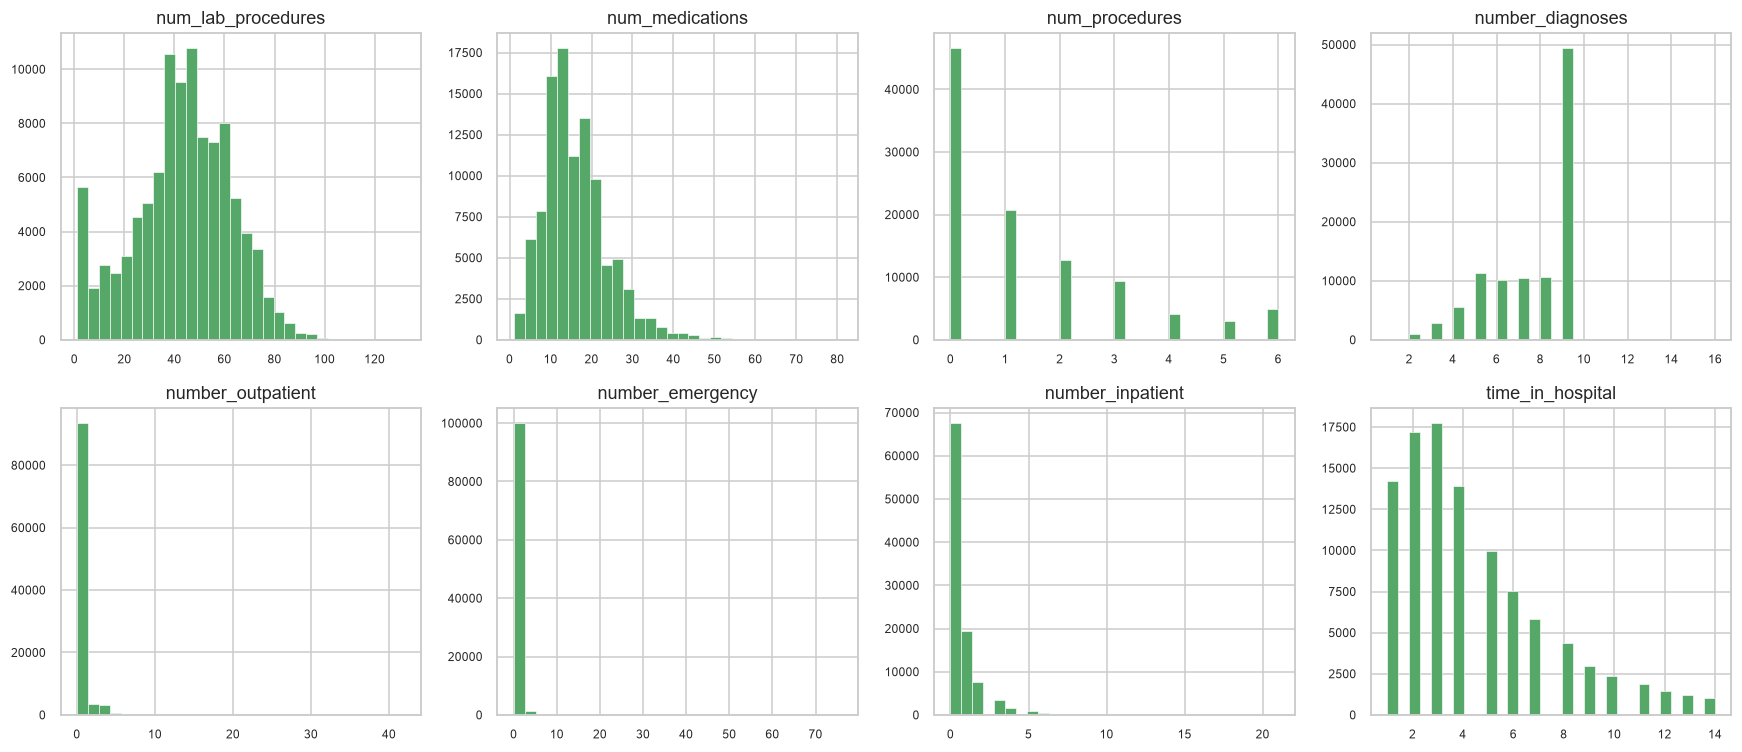

In [5]:
num_cols = [
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
    "number_diagnoses",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "time_in_hospital",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(
        df[col], bins=30, color=sns.color_palette("deep")[2], edgecolor="white", lw=0.4
    )
    ax.set(title=col, ylabel="")
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

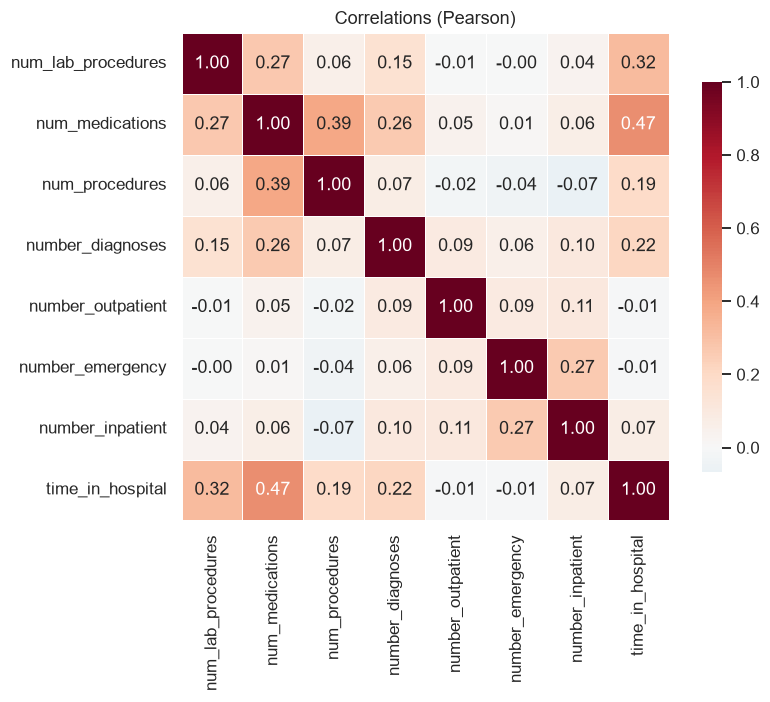

Correlations avec la cible, par ordre decroissant :
num_medications       0.466
num_lab_procedures    0.318
number_diagnoses      0.220
num_procedures        0.191
number_inpatient      0.074
number_outpatient    -0.009
number_emergency     -0.010


In [6]:
# Correlations de Pearson entre variables numeriques.
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlations (Pearson)")
plt.tight_layout()
plt.show()

print("Correlations avec la cible, par ordre decroissant :")
print(
    corr["time_in_hospital"]
    .drop("time_in_hospital")
    .sort_values(ascending=False)
    .round(3)
    .to_string()
)

**Lecture.** `num_medications` (~0,47) et `num_lab_procedures` (~0,32) sont les
predicteurs numeriques les plus correles a la duree. Rien d'etonnant : plus le
sejour dure, plus on prescrit et plus on analyse. Attention a la lecture causale —
ces variables sont mesurees *pendant* le sejour, elles en sont autant une
consequence qu'une cause.

## 5. Independance des observations — le point critique

L'hypothese d'**echangeabilite**, requise par la prediction conforme, suppose des
observations independantes. Or un meme patient peut apparaitre plusieurs fois.

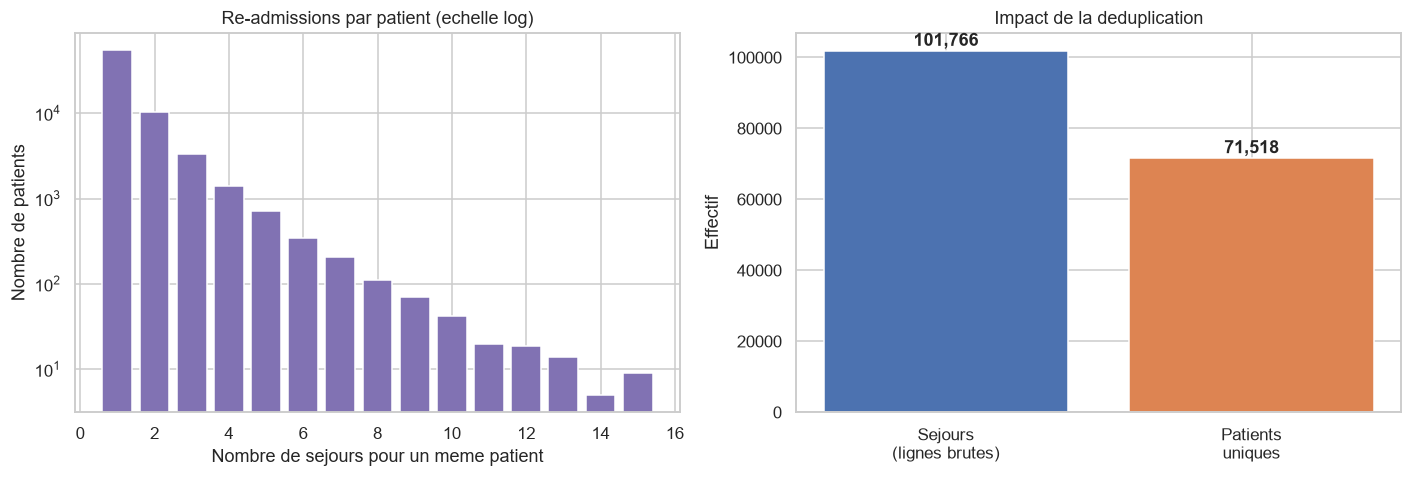

Sejours          : 101,766
Patients uniques : 71,518
Re-admissions    : 30,248 (29.7 % des lignes)
Max de sejours pour un seul patient : 40


In [7]:
n_sejours = len(df)
n_patients = df["patient_nbr"].nunique()
sejours_par_patient = df["patient_nbr"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vc = sejours_par_patient.value_counts().sort_index()
axes[0].bar(vc.index[:15], vc.values[:15], color=sns.color_palette("deep")[4])
axes[0].set(
    xlabel="Nombre de sejours pour un meme patient",
    ylabel="Nombre de patients",
    yscale="log",
    title="Re-admissions par patient (echelle log)",
)

axes[1].bar(
    ["Sejours\n(lignes brutes)", "Patients\nuniques"],
    [n_sejours, n_patients],
    color=[sns.color_palette("deep")[0], sns.color_palette("deep")[1]],
)
for i, v in enumerate([n_sejours, n_patients]):
    axes[1].text(i, v + 1500, f"{v:,}", ha="center", fontweight="bold")
axes[1].set(ylabel="Effectif", title="Impact de la deduplication")

plt.tight_layout()
plt.show()

perdu = n_sejours - n_patients
print(f"Sejours          : {n_sejours:,}")
print(f"Patients uniques : {n_patients:,}")
print(f"Re-admissions    : {perdu:,} ({perdu/n_sejours*100:.1f} % des lignes)")
print(f"Max de sejours pour un seul patient : {sejours_par_patient.max()}")

**Consequence methodologique.** On conserve la **premiere admission de chaque
patient** et on ecarte les suivantes : 29,7 % des lignes, un cout eleve mais non
negociable.

Sans cela, un meme patient pourrait se retrouver a la fois dans le train et dans le
set de calibration. La couverture a 90 % mesuree serait alors optimiste — le modele
aurait deja "vu" ce patient. La garantie conforme deviendrait un chiffre sans valeur.

C'est le genre d'erreur qui ne fait pas planter le code et ne se voit dans aucune
metrique : elle se voit uniquement en relisant le protocole.

## 6. Diagnostics ICD-9

`diag_1`, `diag_2`, `diag_3` : diagnostic principal et secondaires.

diag_1 : 716 codes distincts
diag_2 : 748 codes distincts
diag_3 : 789 codes distincts

Codes commencant par V ou E : 1645


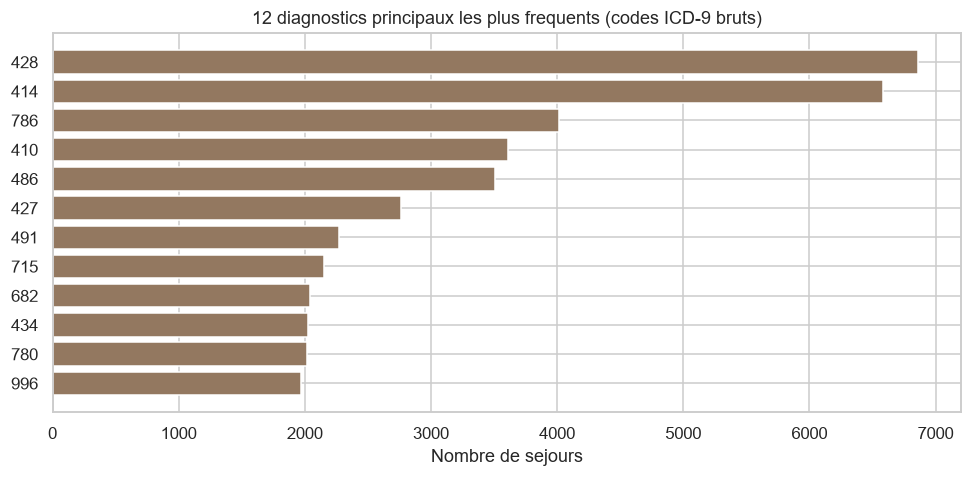

In [8]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(f"{col} : {df[col].nunique()} codes distincts")

# Les codes V (facteurs influencant l'etat de sante) et E (causes externes) ne
# sont pas numeriques : tout regroupement qui ferait float(code) planterait dessus.
codes = df["diag_1"].dropna().astype(str)
print(f"\nCodes commencant par V ou E : {codes.str.match(r'^[VE]').sum()}")

fig, ax = plt.subplots(figsize=(9, 4.5))
top = df["diag_1"].value_counts().head(12)
ax.barh(
    [str(i) for i in top.index][::-1],
    top.values[::-1],
    color=sns.color_palette("deep")[5],
)
ax.set(
    xlabel="Nombre de sejours",
    title="12 diagnostics principaux les plus frequents (codes ICD-9 bruts)",
)
plt.tight_layout()
plt.show()

**Lecture.** Pres de 800 codes distincts par colonne : inexploitable tel quel
(cardinalite trop elevee, modalites a tres faible effectif).

Les codes dominants sont coherents avec une population diabetique :
`428` insuffisance cardiaque, `414` cardiopathie ischemique, `410` infarctus,
`486` pneumonie, `427` troubles du rythme.

**A retenir pour `preprocess.py`** : le regroupement en categories cliniques larges
(circulatoire, respiratoire, digestif, diabete, blessure, musculosquelettique,
genito-urinaire, neoplasmes, autre) devra traiter explicitement les **1 645 codes
V/E**, qui ne se convertissent pas en nombre.

## Synthese — decisions pour `src/data/preprocess.py`

| Element | Decision | Justification |
|---|---|---|
| `?` | -> `NaN` | encodage du manquant propre au dataset |
| `weight` | drop | 96,9 % manquant |
| `max_glu_serum`, `A1Cresult` | garder, `"not_measured"` | test non fait = information clinique |
| `medical_specialty` | garder, manquants -> `"Unknown"` | signal le plus fort (3,3 j d'ecart) |
| `payer_code` | **garder** | mesurer l'inegalite plutot que l'esquiver ; controle en phase 5 par sous-groupe |
| `diag_1/2/3` | regrouper en categories cliniques | ~800 codes -> ~9 categories ; gerer les codes V/E |
| Doublons `patient_nbr` | **premiere admission seulement** | echangeabilite requise par le conforme |
| Encodage | ordinal / categoriel natif LightGBM | evite un one-hot massif |

Etape suivante : `src/data/split.py` — split 60/20/20 stratifie sur la cible,
calcule **une seule fois** et sauvegarde.